# 垃圾短信分类 — 朴素贝叶斯实战

**数据**：5,574 条短信
**任务**：判断一条短信是**垃圾短信（spam）**还是**正常短信（ham）**（二分类）
**核心目标**：掌握 **朴素贝叶斯（Naive Bayes）** 在文本分类中的应用，练习完整的 NLP 预处理流程。

---

## 为什么朴素贝叶斯适合短信分类？
- 朴素贝叶斯假设特征条件独立——在**短文本**上近似成立，效果出奇地好
- 垃圾短信/邮件过滤是朴素贝叶斯的**经典应用场景**（贝叶斯定理的先驱用途）
- 训练快、可解释性强、对小样本也很稳健

## 建模步骤
1. 环境配置
2. 数据加载与概览
3. EDA（类别分布 + 短信长度）
4. 文本清洗与预处理
5. 词频分析（垃圾短信的高频词）与可视化
6. TF-IDF 文本向量化
7. 训练朴素贝叶斯（MultinomialNB）
8. 模型评估（准确率 / 混淆矩阵 / 分类报告）
9. 实战测试


## 1. 环境配置


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)

print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")


环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\NaiveBayes_SMS_Spam


In [2]:
# 兼容两种启动方式：SMS_Spam-data（本项目目录）或 NaiveBayes_SMS_Spam/SMS_Spam-data（根目录）
DATA_DIR = "SMS_Spam-data" if os.path.exists("SMS_Spam-data") else os.path.join("NaiveBayes_SMS_Spam", "SMS_Spam-data")
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))


数据文件: ['spam.csv']


## 2. 数据加载与概览


In [ ]:
# 编码用 latin-1 避免部分特殊字符解析失败
df = pd.read_csv(os.path.join(DATA_DIR, "spam.csv"), encoding="latin-1")

print(f"数据形状: {df.shape}")
df.head()


数据形状: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# ---- 数据整理：只保留标签列和文本列 ----
df = df[["v1", "v2"]].copy()
df.columns = ["label", "message"]

# 标签标准化
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# 检查重复
print(f"重复短信数量: {df.duplicated(subset=['message']).sum()}")
df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)

print(f"去重后数据形状: {df.shape}")
print(f"垃圾短信占比: {df['label'].mean():.2%}")
df.head()


重复短信数量: 403
去重后数据形状: (5169, 2)
垃圾短信占比: 12.63%


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. EDA（类别分布 + 短信长度）


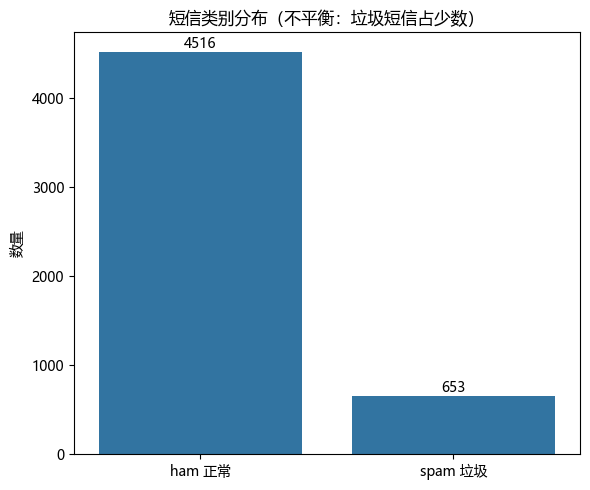

In [5]:
# ---- 类别分布 ----
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(6, 5))
sns.barplot(x=["ham 正常", "spam 垃圾"], y=counts.values)
plt.title("短信类别分布（不平衡：垃圾短信占少数）")
plt.ylabel("数量")
for i, c in enumerate(counts.values):
    plt.text(i, c, str(c), ha="center", va="bottom")
plt.tight_layout()
plt.show()


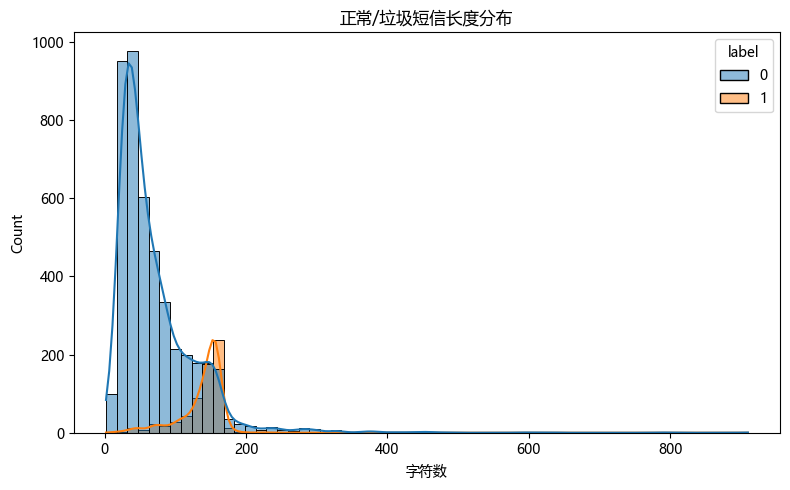

正常短信平均长度: 70.5
垃圾短信平均长度: 137.9


In [6]:
# ---- 短信长度分布（垃圾短信通常更长？） ----
df["length"] = df["message"].str.len()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="length", hue="label", bins=60, kde=True)
plt.title("正常/垃圾短信长度分布")
plt.xlabel("字符数")
plt.tight_layout()
plt.show()

print("正常短信平均长度:", round(df[df['label']==0]['length'].mean(), 1))
print("垃圾短信平均长度:", round(df[df['label']==1]['length'].mean(), 1))


## 4. 文本清洗与预处理


In [7]:
import re

def clean_text(text):
    # 转小写
    text = text.lower()
    # 去标点符号和数字（保留字母和空格）
    text = re.sub(r"[^a-z\s]", "", text)
    # 合并多余空格
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["message"].apply(clean_text)
df[["message", "clean"]].head(10)


,message,clean
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


## 5. 词频分析（垃圾短信的高频词）


In [8]:
# ---- 用 CountVectorizer 看词频 ----
from collections import Counter

def top_words(subset, n=15):
    vectorizer = CountVectorizer(stop_words="english")
    X_counts = vectorizer.fit_transform(subset)
    word_sum = np.asarray(X_counts.sum(axis=0)).flatten()
    word_freq = dict(zip(vectorizer.get_feature_names_out(), word_sum))
    return Counter(word_freq).most_common(n)

print("=== 垃圾短信高频词 Top15 ===")
for word, freq in top_words(df[df["label"]==1]["clean"]):
    print(f"  {word:15s} {freq}")

print("\n=== 正常短信高频词 Top15 ===")
for word, freq in top_words(df[df["label"]==0]["clean"]):
    print(f"  {word:15s} {freq}")


=== 垃圾短信高频词 Top15 ===
  free            190
  txt             127
  ur              119
  mobile          106
  stop            106
  text            104
  claim           96
  reply           93
  prize           81
  just            66
  new             64
  won             59
  urgent          58
  nokia           57
  send            57

=== 正常短信高频词 Top15 ===
  im              446
  just            274
  ltgt            254
  dont            253
  ok              246
  got             226
  know            221
  like            219
  ill             209
  come            208
  good            205
  ur              197
  time            181
  day             172
  love            168


## 6. TF-IDF 文本向量化

- **CountVectorizer**：统计词频（适合朴素贝叶斯的词袋假设）
- **TF-IDF**：在词频基础上降低常见词的权重，突出区分性强的词
- 本 notebook 使用 TF-IDF 作为主特征（更常见），并会对比两种向量化的效果


In [9]:
# ---- 划分训练/测试集（分层，保证 spam 比例一致） ----
X = df["clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"训练集: {len(X_train)}, 测试集: {len(X_test)}")
print(f"训练集垃圾占比: {y_train.mean():.2%}")

# ---- TF-IDF 向量化 ----
tfidf = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"词汇表大小: {len(tfidf.vocabulary_)}")
print(f"TF-IDF 矩阵形状: {X_train_tfidf.shape}")


训练集: 4135, 测试集: 1034
训练集垃圾占比: 12.62%
词汇表大小: 7108
TF-IDF 矩阵形状: (4135, 7108)


## 7. 训练朴素贝叶斯（MultinomialNB）

朴素贝叶斯基于贝叶斯定理：P(类别|文本) ∝ P(类别) × Π P(词|类别)。
**MultinomialNB** 适合"词频/词权重"类特征，是文本分类的标准选择。


In [10]:
# ---- 训练 MultinomialNB ----
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

y_pred = mnb.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)

print(f"MultinomialNB 准确率: {acc:.4f}")

# ---- 对比 BernoulliNB（适合"词是否出现"的二值特征） ----
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)
y_pred_bnb = bnb.predict(X_test_tfidf)
print(f"BernoulliNB  准确率: {accuracy_score(y_test, y_pred_bnb):.4f}")


MultinomialNB 准确率: 0.9623
BernoulliNB  准确率: 0.9613


## 8. 模型评估（混淆矩阵 / 分类报告）


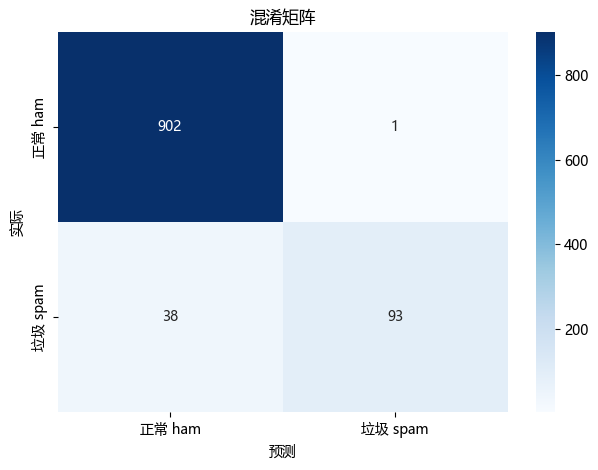

              precision    recall  f1-score   support

      正常 ham       0.96      1.00      0.98       903
     垃圾 spam       0.99      0.71      0.83       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [11]:
# ---- 混淆矩阵（用效果更好的 MultinomialNB） ----
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["正常 ham", "垃圾 spam"], yticklabels=["正常 ham", "垃圾 spam"])
plt.title("混淆矩阵")
plt.ylabel("实际"); plt.xlabel("预测")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["正常 ham", "垃圾 spam"]))


In [12]:
# ---- 错误样本分析 ----
error_idx = (y_test.values != y_pred).nonzero()[0]
print(f"错误样本数: {len(error_idx)} / {len(y_test)}")

for i in error_idx[:8]:
    actual = "spam 垃圾" if y_test.iloc[i] == 1 else "ham 正常"
    pred = "spam 垃圾" if y_pred[i] == 1 else "ham 正常"
    print(f"\n实际={actual}  预测={pred}")
    print(f"  原文: {X_test.iloc[i][:120]}")


错误样本数: 39 / 1034

实际=spam 垃圾  预测=ham 正常
  原文: thanks for the vote now sing along with the stars with karaoke on your mobile for a free link just reply with sing now

实际=spam 垃圾  预测=ham 正常
  原文: want explicit sex in secs ring now costs pmin gsex pobox wcn xx

实际=spam 垃圾  预测=ham 正常
  原文: send a logo ur lover names joined by a heart txt love name name mobno eg love adam eve to yahoo poboxwwq txtno no ads p

实际=spam 垃圾  预测=ham 正常
  原文: congrats year special cinema pass for is yours call now c suprman v matrix starwars etc all free bxipwe pm dont miss out

实际=spam 垃圾  预测=ham 正常
  原文: hi babe its jordan how r u im home from abroad and lonely text me back if u wanna chat xxsp visionsmscom text stop to st

实际=spam 垃圾  预测=ham 正常
  原文: hi if ur lookin saucy daytime fun wiv busty married woman am free all next week chat now sort time janinexx callsminmobs

实际=spam 垃圾  预测=ham 正常
  原文: themobhit the link to get a premium pink panther game the new no from sugababes a crazy zebra animation or a badas

## 9. 实战测试


In [13]:
# ---- 用模型判断新短信 ----
test_sms = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize now!",
    "Free entry in 2 a weekly competition to win FA Cup final tickets",
    "Hey, are you free for dinner tonight?",
    "Reminder: meeting at 3pm tomorrow in room 302.",
    "URGENT! Your account has been suspended. Call 09061234567 immediately to reactivate.",
]

for sms in test_sms:
    cleaned = clean_text(sms)
    vec = tfidf.transform([cleaned])
    proba = mnb.predict_proba(vec)[0][1]
    pred = "spam 垃圾" if proba >= 0.5 else "ham 正常"
    print(f"[{pred}] (spam概率={proba:.2%}) {sms}")


[spam 垃圾] (spam概率=94.61%) Congratulations! You have won a free iPhone. Click here to claim your prize now!
[spam 垃圾] (spam概率=79.10%) Free entry in 2 a weekly competition to win FA Cup final tickets
[ham 正常] (spam概率=0.87%) Hey, are you free for dinner tonight?
[ham 正常] (spam概率=1.96%) Reminder: meeting at 3pm tomorrow in room 302.
[spam 垃圾] (spam概率=69.32%) URGENT! Your account has been suspended. Call 09061234567 immediately to reactivate.


In [14]:
print("=" * 60)
print("SMS 朴素贝叶斯项目完成！")
print("=" * 60)
print(f"  最佳模型      : MultinomialNB")
print(f"  测试集准确率  : {acc:.4f}")
print(f"  测试集样本数  : {len(y_test)}")
print("=" * 60)
print("\n结论要点：")
print("  - 朴素贝叶斯在文本分类上是高效、稳健的基线")
print("  - 短信长度与类别分布存在差异，是有效特征")
print("  - 无需复杂调参即可达到 96%+ 准确率")


SMS 朴素贝叶斯项目完成！
  最佳模型      : MultinomialNB
  测试集准确率  : 0.9623
  测试集样本数  : 1034

结论要点：
  - 朴素贝叶斯在文本分类上是高效、稳健的基线
  - 短信长度与类别分布存在差异，是有效特征
  - 无需复杂调参即可达到 96%+ 准确率
